In [5]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [6]:
os.getcwd()

'/content'

In [7]:
df = pd.read_csv("cleaned_data_updated.csv")
df.head()

,BOROUGH,ZIP_CODE,LATITUDE_CRASH,LONGITUDE_CRASH,ON_STREET_NAME,CROSS_STREET_NAME,NUMBER_OF_PERSONS_INJURED,NUMBER_OF_PERSONS_KILLED,NUMBER_OF_PEDESTRIANS_INJURED,NUMBER_OF_PEDESTRIANS_KILLED,...,TMIN,CRASH_DATETIME,YEAR,MONTH,DAY,HOUR,VEHICLE_TYPE_CODE_1_REGROUP,VEHICLE_TYPE_CODE_2_REGROUP,RUSH_HOUR,SEASON
0,BROOKLYN,11230.0,40.621790,-73.970024,OCEAN PARKWAY,AVENUE K,1.0,0.0,0,0,...,41.781166,2023-11-01 01:29:00,2023,11,1,1,Motorcycles and Scooters,Passenger Car,0,Fall
1,BROOKLYN,11208.0,40.667202,-73.866500,MISSING,MISSING,0.0,0.0,0,0,...,64.357370,2021-09-11 09:35:00,2021,9,11,9,Passenger Car,Unknown Vehicle,1,Fall
2,BROOKLYN,11233.0,40.683304,-73.917274,SARATOGA AVENUE,DECATUR STREET,0.0,0.0,0,0,...,33.819177,2021-12-14 08:13:00,2021,12,14,8,Unknown Vehicle,Unknown Vehicle,1,Winter
3,MISSING,11249.0,40.709183,-73.956825,BROOKLYN QUEENS EXPRESSWAY,MISSING,0.0,0.0,0,0,...,33.819177,2021-12-14 17:05:00,2021,12,14,17,Passenger Car,Unknown Vehicle,1,Winter
4,BRONX,10475.0,40.868160,-73.831480,MISSING,MISSING,2.0,0.0,0,0,...,44.000000,2021-12-14 08:17:00,2021,12,14,8,Passenger Car,Passenger Car,1,Winter


In [8]:
combined_borough_df = pd.concat([
    df[["BOROUGH", "ZIP_CODE", "RUSH_HOUR", "VEHICLE_TYPE_CODE_1_REGROUP"]].rename(columns={"VEHICLE_TYPE_CODE_1_REGROUP": "VEHICLE"}),
    df[["BOROUGH", "ZIP_CODE", "RUSH_HOUR", "VEHICLE_TYPE_CODE_2_REGROUP"]].rename(columns={"VEHICLE_TYPE_CODE_2_REGROUP": "VEHICLE"})
])
combined_borough_df = combined_borough_df.dropna()
combined_borough_df.head()

,BOROUGH,ZIP_CODE,RUSH_HOUR,VEHICLE
0,BROOKLYN,11230.0,0,Motorcycles and Scooters
1,BROOKLYN,11208.0,1,Passenger Car
2,BROOKLYN,11233.0,1,Unknown Vehicle
3,MISSING,11249.0,1,Passenger Car
4,BRONX,10475.0,1,Passenger Car


Accident distribution by vehicle type, bar chart
- X axis: main vehicle type
- Y axis: total number of accidents

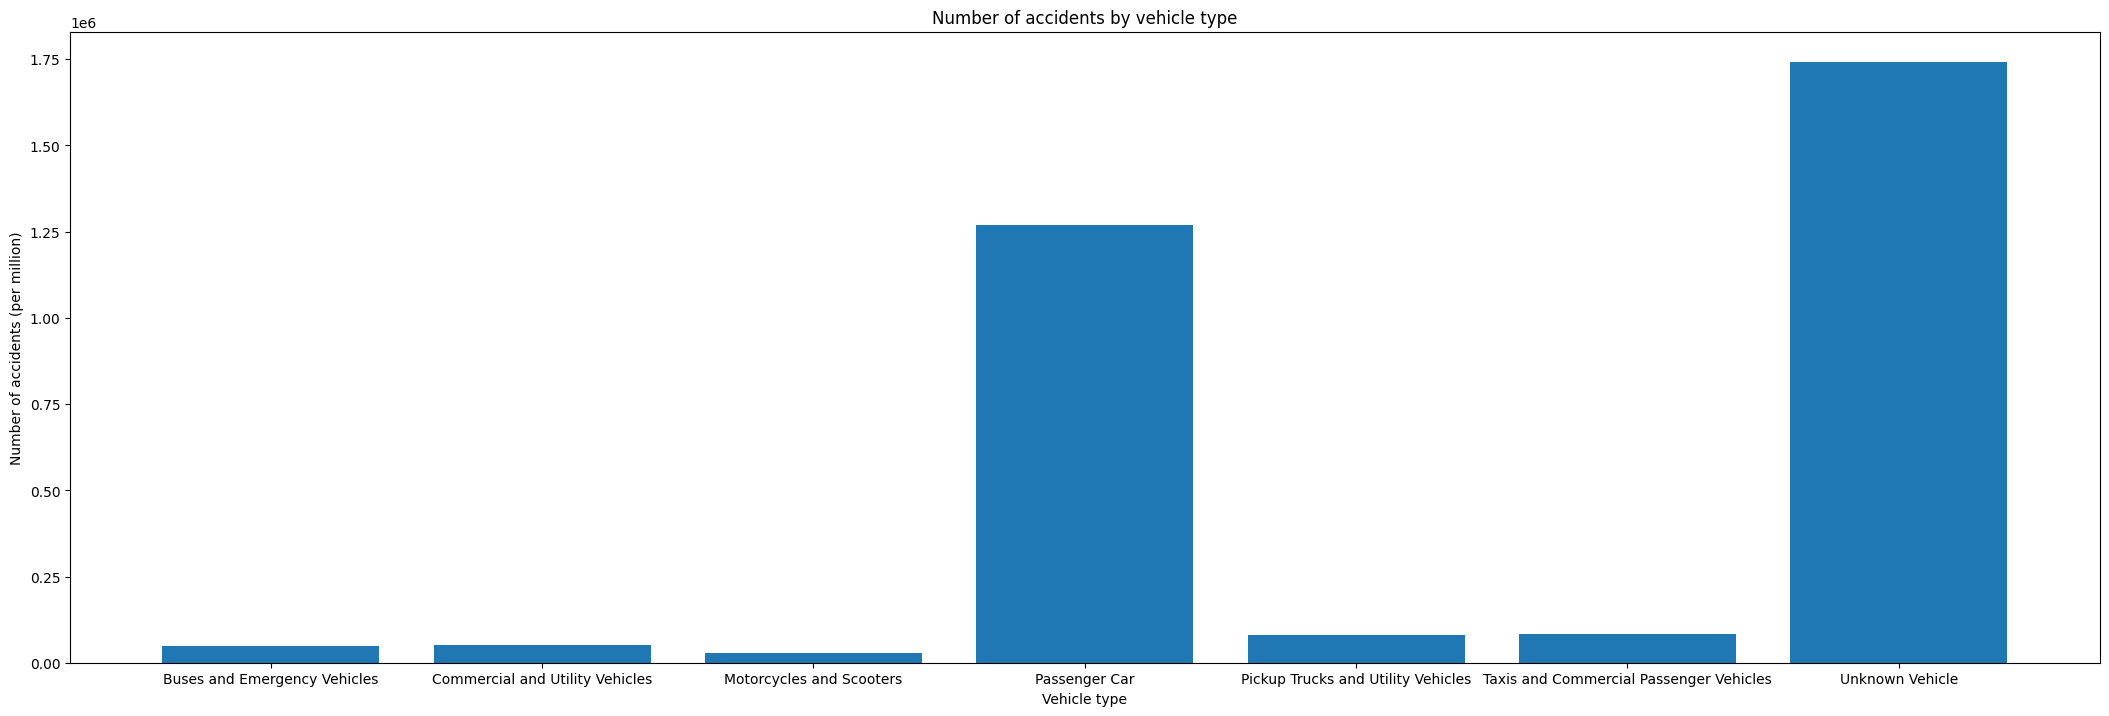

<Figure size 640x480 with 0 Axes>

In [10]:
grouped_by_vehicle_type = combined_borough_df.groupby('VEHICLE').count().reset_index()
grouped_by_vehicle_type.drop(index=[6, 7], inplace=True) # dropping trailers and tractors for low count
plt.figure(figsize=(21, 7))
plt.bar(grouped_by_vehicle_type['VEHICLE'], grouped_by_vehicle_type['BOROUGH'])
plt.tight_layout()
plt.title("Number of accidents by vehicle type")
plt.xlabel("Vehicle type")
plt.ylabel("Number of accidents (per million)")
plt.show()
plt.savefig("output/number_of_accidents_by_vehicle_type.png")

Vehicle type vs. Borough, stacked bar chart or heatmap
- X axis: main vehicle type
- Y axis: total number of accidents
- Stacked: Borough

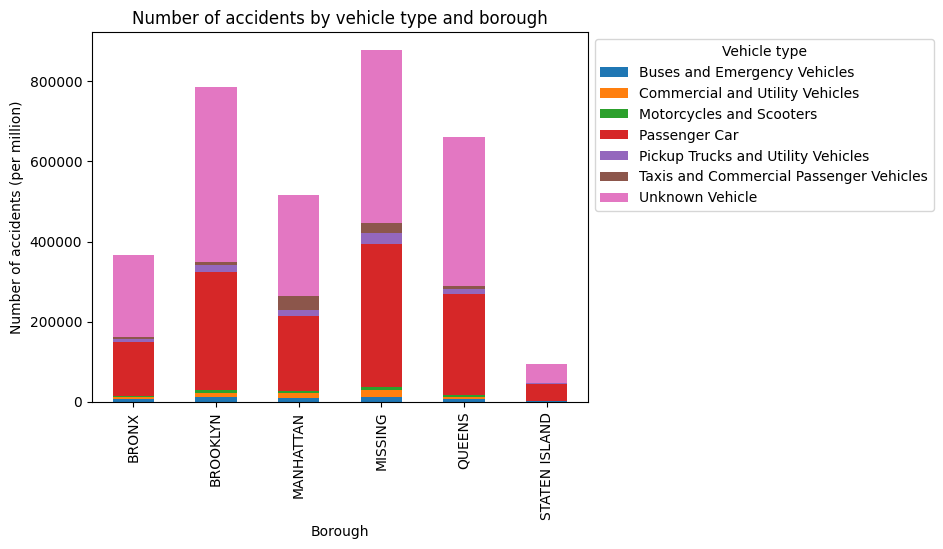

In [24]:
fig, ax = plt.subplots()

grouped_by_vehicle_type_borough = combined_borough_df.groupby(['VEHICLE', 'BOROUGH']).count().reset_index()
values_to_drop = ['Tractors and Heavy Duty Vehicles', 'Trailers']
index_to_drop = grouped_by_vehicle_type_borough[grouped_by_vehicle_type_borough['VEHICLE'].isin(values_to_drop)].index
grouped_by_vehicle_type_borough.drop(index_to_drop, inplace=True)

grouped_by_vehicle_type_borough.pivot_table(index='BOROUGH', columns='VEHICLE', values='ZIP_CODE').plot(kind='bar', stacked=True, ax=ax)
ax.legend(title='Vehicle type', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.title("Number of accidents by vehicle type and borough")
plt.xlabel("Borough")
plt.ylabel("Number of accidents (per million)")
plt.savefig("output/number_of_accidents_by_vehicle_type_and_borough.png")

Rush hour and Vehicle type, stacked bar chart
- X axis: rush hour category (rush hour, non-rush hour)
- Y axis: total number of accidents
- Stacked: top vehicle types

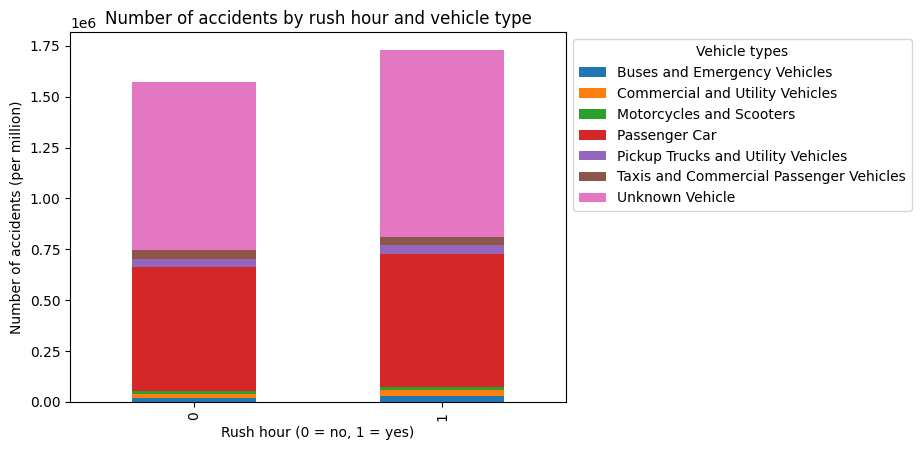

In [25]:
fig, ax = plt.subplots()

grouped_by_vehicle_type_rush_hour = combined_borough_df.groupby(['RUSH_HOUR', 'VEHICLE']).count().reset_index()
grouped_by_vehicle_type_rush_hour.head()

vtd = ['Tractors and Heavy Duty Vehicles', 'Trailers']
idx = grouped_by_vehicle_type_rush_hour[grouped_by_vehicle_type_rush_hour['VEHICLE'].isin(vtd)].index
grouped_by_vehicle_type_rush_hour.drop(idx, inplace=True)

grouped_by_vehicle_type_rush_hour.pivot_table(index='RUSH_HOUR', columns='VEHICLE', values='ZIP_CODE').plot(kind='bar', stacked=True, ax=ax)
ax.legend(title='Vehicle types', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.title("Number of accidents by rush hour and vehicle type")
plt.xlabel("Rush hour (0 = no, 1 = yes)")
plt.ylabel("Number of accidents (per million)")
plt.savefig("output/number_of_accidents_by_rush_hour_and_vehicle_type.png")